      product  total_qty   revenue
0  Headphones         15   22500.0
1      Laptop          8  400000.0
2      Mobile         15  300000.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

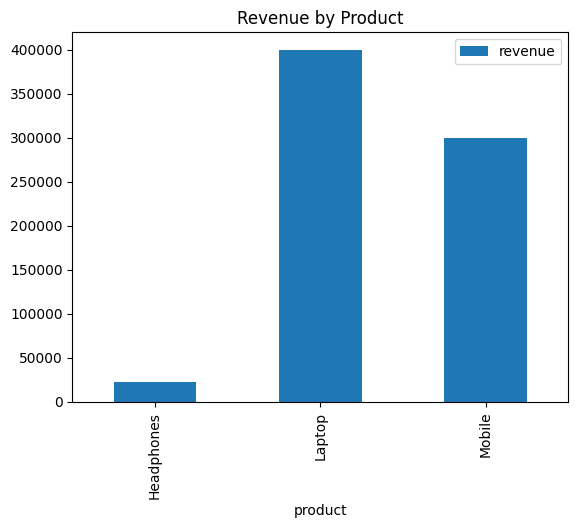


Total Revenue
   total_revenue
0       722500.0


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect("sales_data.db")
cur = conn.cursor()

# Create table
cur.execute("""
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Add sample data
cur.execute("DELETE FROM sales")

data = [
    ("Laptop", 5, 50000),
    ("Mobile", 10, 20000),
    ("Headphones", 15, 1500),
    ("Laptop", 3, 50000),
    ("Mobile", 5, 20000)
]

cur.executemany("INSERT INTO sales VALUES (?, ?, ?)", data)
conn.commit()

# SQL query
query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity*price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)

# Display results
print(df)

#Database
from google.colab import files

files.download("sales_data.db")
# Bar chart
df.plot(kind="bar", x="product", y="revenue")
plt.title("Revenue by Product")
plt.savefig("sales_chart.png")
plt.show()

total = pd.read_sql_query(
    "SELECT SUM(quantity*price) AS total_revenue FROM sales",
    conn
)

print("\nTotal Revenue")
print(total)

conn.close()